<br>
<img src="ceo.png" style="float: right; margin-left: 15px; margin-bottom: 10px;" width="200"/> You're a top statistician (or data scientist, whichever sounds fanciest to your ear) who's just been hired on a consulting mission for an established company. You're seated with the CEO, and they're telling you they want to overhaul the firm's workforce. They've compiled some data on employee performance and from the firm's financial reports for you, and they're pretty confident that a subset of their employees does the majority of the work while the others are mostly busy scrolling on Tiktok pretending to work. They also believe the quantity of energy drink that an employee downs every day is linearly associated with revenue and a highly accurate indicator of employee productivity...

So they basically want you to perform "employee selection" by modelling the daily company revenue with their energy drink intake. A plethora of questions starts rushing to your head

>*"maybe I should use the Lasso since it can shrink the coefficients of some employees to zero... but how does it do that, by the way? Also, should I prioritise finding the set of employees that best predicts the company revenue, or the smallest decently predictive one that will get the most employees fired thereby saving the firm money?"*

; the consequences are not yours to bear anyway. You're just here to give advice.

<center><img src="lasso-ridge.png" alt="drawing" width="700"/></center>


The image above comes from *Elements of Statistical Learning* (*ESL*) by Hastie, Tibshirani and Friedman. It's a very nice visualisation (also perfectly correct mathematically, not taking that away) which gives you the gist of Lasso (left in image) vs Ridge (right in image) and why one can zero out slope coefficients and the other not. However if you want an actual mental image of the math behind it that gave birth to this result, you'd need to prove that the smallest red contour of the cost function to intersect with the boundary of the Lasso penalty region defined by $|\beta_1|+|\beta_2|\leq t$ does so at a corner, which is not immediately straightforward to me at least (I haven't even tried past what I've just written though...).

The good news is we can also easily show the exact same thing with a bit of high-school level calculus and algebra, in a form that's more familiar to me as a  statistics grad and to some of the readers surely. Depending which branch of math you're most proficient at, you might benefit from knowing the geometric proof over the calculus one. But I find the simplicity and intuitive aspect| of the calculus route hard to beat. And, if you're gonna do some more advanced work on various penalties down the line, it's probably useful to have a clear mental picture of the inner workings of the L1 and L2 penalties in calculus language.

In *ESL*, Hastie et al. spend a large part of the sections on penalised regression describing their Bayesian and geometric interpretations, and only give the algebraic expression of the Ridge coefficients without dwelling on the shape of the Lasso objective and how it helps understand the shrinkage to the exact $0$. So, that's what we're going to be doing in this article.

### Enough with the yapping

For simplicity, throughout this entire post we'll work with a stupidly simple affine function $f$ that strives to model an outcome $y$ with a single feature $x$:
$$
f(x) = \beta_0 + \beta_1x
$$

Our dataset contains $n$ observations.

## Prelude: OLS

In the case of ordinary least squares regression, in order to find the coefficients that give the best fit on our data, we minimise the mean squared residual:
\begin{align*}
\min_{\beta_0,\beta_1}\frac1n\sum_{i=1}^n{(y_i-\beta_0-\beta_1x_i)^2}
\end{align*}

or equivalently

\begin{align*}
\min_{\beta_0,\beta_1}J(\beta_0, \beta_1)
\end{align*}

where $J$ is the cost function, here the mean squared error in the OLS case, but we will stick to "cost" henceforth. Our goal is to find the parameter values where $J$ is minimised:
\begin{align*}
\hat{\beta}_0, \hat{\beta}_1 & = \arg\min_{\beta_0, \beta_1} J(\beta_0, \beta_1)
\end{align*}

Since $J$ is strictly convex we can safely say that if it has one critical point then that point is its global minimum, so we can find $(\hat{\beta}_0, \hat{\beta}_1)$ by solving the following system:
$$
\left\{ \begin{aligned} 
  \frac{\partial J}{\partial \beta_0} = 0 \\
  \frac{\partial J}{\partial \beta_1} = 0
\end{aligned} \right.
$$

Nothing new here. Since OLS is not the focus today, we'll skip the details and move on to the next part right away, but just remember that the system above yields:
$$
\hat\beta_0 = \bar y - \hat\beta_1 \bar x
$$

where the bar denotes the mean of the given variable in the dataset. For any $\hat\beta_1$, this is the value of $\beta_0$ when the partial derivative of $J$ wrt. $\beta_0$ is $0$, or in other words the optimal $\beta_0$ for any given $\hat\beta_1$.

### Interlude: why penalise at all

A penalised regression model adds a regularisation term (or penalty) to the cost function to encourage the shrinkage of coefficients so that their standard error is reduced, which is especially useful when your dataset has high collinearity. I'll directly quote Hastie \& Tibshirani from the *ESL* book again, as I probably can't put it better than they do:


>*When there are many correlated variables in a linear regression model,*
>*their coefficients can become poorly determined and exhibit high variance.*
>*A wildly large positive coefficient on one variable can be canceled by a*
>*similarly large negative coefficient on its correlated cousin. By imposing a*
>*size constraint on the coefficients, [...] this problem is alleviated.*


## Ridge

Now let's move on to Ridge regression, which is a type of penalised linear regression. Ridge adds what we call the "L2 penalty" to the cost:

\begin{align*}
J(\beta_0, \beta_1) & = \frac1n\sum_{i=1}^n{(y_i-\beta_0-\beta_1x_i)^2} + \lambda\beta_1^2
\end{align*}

The name of this penalty comes from the fact that it is the squared L2 norm of the coefficient vector, which we multiply by $\lambda$ to adjust the strength of the regularisation. Since our model here has just one feature, the L2 norm is just the squared slope coefficient. $J$ being a sum of parabola in $\beta_1$, the shape of the Ridge objective is also a parabola, though not continuous at $\beta_1=0$ (unless the dataset fulfills some conditions which you'll see below, in which case $\beta_1$ would always be $0$ for all $\lambda$ anyway).

In order to minimise $J$, we solve the same system as for OLS. Since the L2 penalty does not depend on $\beta_0$, $\hat\beta_0$ has the same expression as for OLS, so we use the result from the OLS section to substitute $\hat\beta_0$ with its expression in the following. Thus, we're just left with solving (the hats were omitted for notational simplicity):

$$
\begin{align*}
& \frac{\partial J}{\partial \beta_1} = \frac{\partial}{\partial \beta_1} \left( \frac1n\sum_{i=1}^n{(y_i-\beta_0-\beta_1x_i)^2} + \lambda\beta_1^2 \right) = 0 \\
& \Rightarrow \frac1n\sum_{i}{-2x_i(y_i-\beta_0-\beta_1x_i)} + 2\lambda \beta_1 = 0 \tag*{\small we can divide all by 2}\\
& \Leftrightarrow \frac1n\left( \beta_1n\overline{x^2} + \sum_i{x_i(\beta_0-y_i}) \right) + \lambda \beta_1 = 0 \tag*{\small where $\overline{x^2} = \frac1n\sum_i{x_i^2}$} \\
& \Leftrightarrow \beta_1\overline{x^2} + \bar x\bar y - \beta_1\bar x^2 - \overline{xy} + \lambda\beta_1 = 0 \; \tag*{\small where $\overline{xy} = \frac1n\sum_i{x_iy_i}$} \\
& \Leftrightarrow \beta_1(\overline{x^2} + \lambda - \bar x^2) = \overline{xy} - \bar x\bar y
\end{align*}
$$

and by isolating $\beta_1$:

$$
\begin{align*}
\hat\beta_1 & = \frac{\overline{xy} - \bar x\bar y}{\overline{x^2} - \bar x^2 + \lambda}
\end{align*}
$$

Now, for the sake of mathematical rigour, we'll consider the dataset fixed, $\boldsymbol{x}$ and $\boldsymbol{y}$ are not both $\boldsymbol{0}$, and both don't have infinite values. Then if we make $\lambda$ very large the denominator will also become very large, and $\hat\beta_1$ very small:

$$
\lim_{\lambda \to +\infty}\hat\beta_1 = 0
$$

However that limit can never be reached for a finite $\lambda$: that is why in real applications Ridge can shrink coefficients, but never zero them out.

### Conclusion
the slope coefficient is inversely proportional to the regularisation strength $\lambda$, so as you increase the latter to very large values, the slope is shrunk toward 0. Since 0 is the limit of $\hat\beta_1$ which is only reached when $\lambda$ is infinite, Ridge never zeroes out coefficients in practice.

## LASSO

Onto the Lasso, another type of penalised regression. The Lasso adds the L1 penalty to the mean squared error: instead of L2 norm, we're now working with the L1 norm which is the sum of the absolute coefficients. Thankfully our model is very simple, so the L1 norm is just the absolute value of the slope here. Our cost function is now:
$$
\begin{align*}
J(\beta_0, \beta_1) & = \frac1n \sum_{i=1}^n{(y_i-\beta_0-\beta_1x_i)^2} + \lambda|\beta_1|
\end{align*}
$$

and we're solving the same optimisation problem as with Ridge earlier. Since $J$ is the sum of a parabola and absolute value, the objective is not smooth and looks like a straightened parabola axially asymmetric around the vertical line at its minimum.

The MSE part in $\partial_{\beta_1} J$ is the same, so we can take its expanded expression from the previous section and fix the penalty part while not forgetting to also divide it by 2 (which we'd already done for Ridge earlier):

\begin{align*}

\beta_1(\overline{x^2} - \bar x^2) + \bar x\bar y - \overline{xy} + \frac12\frac{\partial}{\partial \beta_1}(\lambda |\beta_1|) & = 0 \\

\text{given} \frac{\partial}{\partial \beta_1}(|\beta_1|) = \frac{\beta_1}{|\beta_1|} = \text{sgn$(\beta_1)$,} \\

\Leftrightarrow \beta_1(\overline{x^2} - \bar x^2) + \bar x\bar y - \overline{xy} + \frac12 \text{sgn$(\beta_1)$}\lambda & = 0
\end{align*}

and by isolating $\beta_1$:

$$
\hat\beta_1 = \frac{\overline{xy} - \bar x\bar y - \frac12 \text{sgn}(\beta_1) \lambda}{\overline{x^2} - \bar x^2} \;,\; \text{where sgn$(\beta_1)$} =
\left\{ \begin{aligned}
+ \;\; \text{if $\hat\beta_1 > 0$} \\
- \;\; \text{if $\hat\beta_1 < 0$} 
\end{aligned} \right.
$$

Pay attention to the numerator of $\hat\beta_1$ and notice how if we crank up the regularisation strength such that $\lambda \geq 2(\overline{xy} - \bar x\bar y)$, then we run into an issue, because the very assumptions under which $\hat\beta_1$ was defined above break in *both* cases of $\text{sgn}$ $(\beta_1)$; let $\lambda_{lim}=2(\overline{xy} - \bar x\bar y)$ and the $\hat\beta_1$ formula above yields

- $\hat\beta_1 \leq 0$ in the case $\hat\beta_1 > 0$, since $\lambda \geq \lambda_{lim}$ makes the numerator 0 or negative,
- $\hat\beta_1 \geq 0$ in the case $\hat\beta_1 < 0$, since $\lambda \geq \lambda_{lim}$ makes the numerator 0 or positive.

In other words $\hat\beta_1$ does not lie in the interval that the assumption about its sign said. Sounds confusing. This mess basically means that since those assumptions are violated when we increase $\lambda$ past $\lambda_{lim}$, the minimum of $J$ is not reached when $\hat\beta_1 > 0$ nor when $\hat\beta_1 < 0$.

What's left? We know that since $J$ is strictly convex (the MSE is strictly convex, and the absolute value is convex), continuous in $\beta_1$ on $\mathbb{R}$ (it doesn't have any breaks), and coercive $(\lim_{\beta_1 \to \pm \infty}J=+\infty)$, its global minimum is guaranteed to exist. So the only possibility we're left with for that minimum is $\hat\beta_1 = 0$, even though $\partial_{\beta_1} J$ is not defined at $\hat\beta_1 = 0$. This is a nice example that illustrates why differentiability is not a necessary condition for a minimum !

### Let's visualise the Lasso shrinkage in action!

We're going to generate a small mock dataset with 20 data points ($x,y$). It doesn't really matter which distribution $x$ comes from, and we'll make it so $y$ is partly but not perfectly explained by $x$.

Here's a very ugly scatter plot to visualise the dependency between $x$ and $y$:

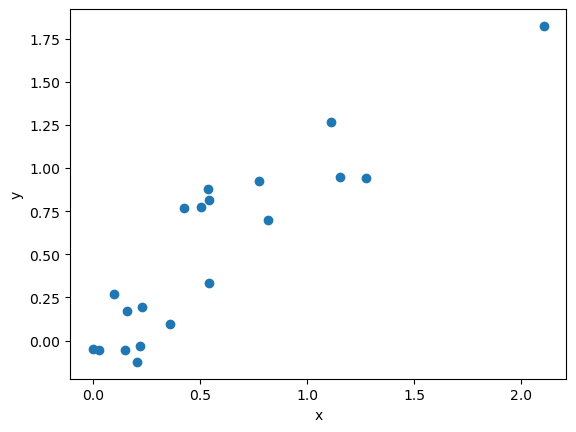

In [1]:
import numpy as np
import matplotlib.pyplot as plt

size = 20

np.random.seed(1)
x = np.random.exponential(scale=1, size=size)  #random idea of distro, dont ask me why
y = x + np.random.normal(loc=0, scale=0.3, size=size)  #we make y dependent on x, but add some small gaussian noise

plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Now let's generate a grid of $\beta_0$ and $\beta_1$ values and compute the curve of the cost function:

In [2]:
res = 1_000

beta_1 = np.linspace(-2, 2, res)
beta_0 = np.mean(y) -np.mean(x)*beta_1

def compute_cost(lambda_):
    return [np.mean(np.square(y-beta_0[i]-beta_1[i]*x)) + lambda_*abs(beta_1[i]) for i in range(res)]

Let's start out with a small value, say $\lambda=0.1$, and see what $J$ looks like:

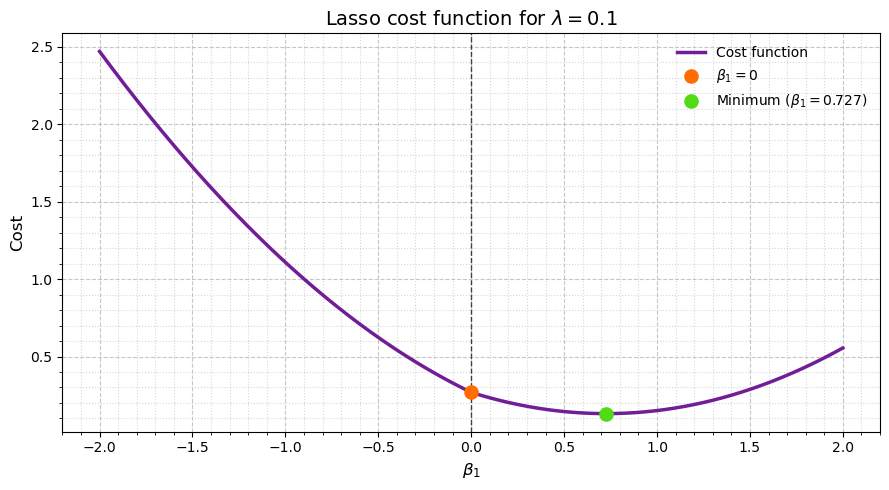

In [12]:
from matplotlib.ticker import MultipleLocator

cost = compute_cost(lambda_=0.1)

min_idx = np.argmin(cost)
beta_min = beta_1[min_idx]
cost_min = cost[min_idx]

zero_idx = np.argmin(np.abs(beta_1 - 0))
cost_zero = cost[zero_idx]

plt.figure(figsize=(9, 5))

plt.plot(
    beta_1,
    cost,
    linewidth=2.5,
    color="#721d98",
    label="Cost function"
)

plt.scatter(
    0,
    cost_zero,
    s=90,
    color="#ff6d00",
    zorder=5,
    label=r"$\beta_1 = 0$"
)

plt.scatter(
    beta_min,
    cost_min,
    s=90,
    color="#51da16",
    zorder=5,
    label=fr"Minimum ($\beta_1={beta_min:.3f}$)"
)

plt.xlabel(r"$\beta_1$", fontsize=12)
plt.ylabel("Cost", fontsize=12)
plt.title(r"Lasso cost function for $\lambda = 0.1$", fontsize=14)

ax = plt.gca()

ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))

ax.grid(which="major", alpha=0.7, linestyle="--")
ax.grid(which="minor", alpha=0.5, linestyle=":")

ax.axvline(
    0,
    linewidth=1,
    alpha=0.7,
    color='black',
    linestyle="--"
)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [4]:
float(round(min(cost), 3))

0.131

The minimum of $J$ is $0.131$ and is reached at $\beta_1=0.727$, so with a weak regularisation of $\lambda=0.1$ the Lasso will keep $\beta_1$ in the model.

Remember that $\lambda_{lim}=2(\overline{xy} - \bar x\bar y)$, so let's find it:

In [5]:
lambda_lim = 2*(np.mean(x*y) - np.mean(x)*np.mean(y))
float(round(lambda_lim, 3))

0.479

It's a bit higher than the value we've just tested, so as we increase $\lambda$ from $0.1$ to $\lambda_{lim}$, we should see the minimum of $J$ slide leftward over to the orange point...

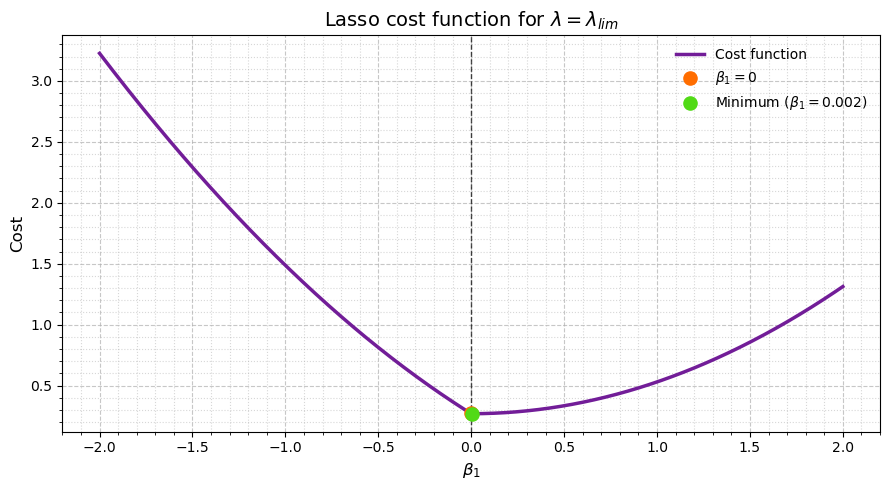

In [13]:
cost = compute_cost(lambda_=lambda_lim)

min_idx = np.argmin(cost)
beta_min = beta_1[min_idx]
cost_min = cost[min_idx]

zero_idx = np.argmin(np.abs(beta_1 - 0))
cost_zero = cost[zero_idx]

plt.figure(figsize=(9, 5))

plt.plot(
    beta_1,
    cost,
    linewidth=2.5,
    color="#721d98",
    label="Cost function"
)

plt.scatter(
    0,
    cost_zero,
    s=90,
    color="#ff6d00",
    zorder=5,
    label=r"$\beta_1 = 0$"
)

plt.scatter(
    beta_min,
    cost_min,
    s=90,
    color="#51da16",
    zorder=5,
    label=fr"Minimum ($\beta_1={beta_min:.3f}$)"
)

plt.xlabel(r"$\beta_1$", fontsize=12)
plt.ylabel("Cost", fontsize=12)
plt.title(r"Lasso cost function for $\lambda = \lambda_{lim}$", fontsize=14)

ax = plt.gca()

ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))

ax.grid(which="major", alpha=0.7, linestyle="--")
ax.grid(which="minor", alpha=0.5, linestyle=":")

ax.axvline(
    0,
    linewidth=1,
    alpha=0.7,
    color='black',
    linestyle="--"
)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Bingo, we've just hit $\beta_1=0$. Notice how as we increase $\lambda$, an "elbow effect" starts to appear $\beta_1=0$, that's the effect of the higher weight we're progressively putting on the absolute value in $J$, which is basically making the absolute value "visually emerge" more in the graph.

Let's see where the minimum of $J$ stands now:

In [7]:
float(round(min(cost), 3))

0.269

With $\lambda=\lambda_{lim}$, $\beta_1$ has been excluded from the model, but notice how the minimum of $J$ is now $0.269$, higher than with $\lambda=0.1$ before? So, maybe the Lasso will tell itself that the ideal amount of regularisation ought not be so high... and that keeping $\beta_1$ in the model may be a good idea as it'll better help explain the variation in $y$.

*Note*: we generated a series of $\beta_1$ with arbitrary resolution hence $\hat\beta_1=0.002$ and not a sharp $0$, as $0.002$ happens to be the closest value we have to $0$ here. But, theoretically, the minimum is reached at $\hat\beta_1=0$ when $\lambda=\lambda_{lim}$, and the feature is ruled out from the model. You're free to rerun this script with a much finer grid of $\beta_1$ and observe how $\hat\beta$ approaches the exact $0$ the finer the grid is.

And from here on, if we keep increasing $\lambda$, the minimum of the objective will stay $\hat\beta_1=0$ ! To illustrate that, let's look at a $\lambda=0.5$ slightly over $\lambda_{lim}$:

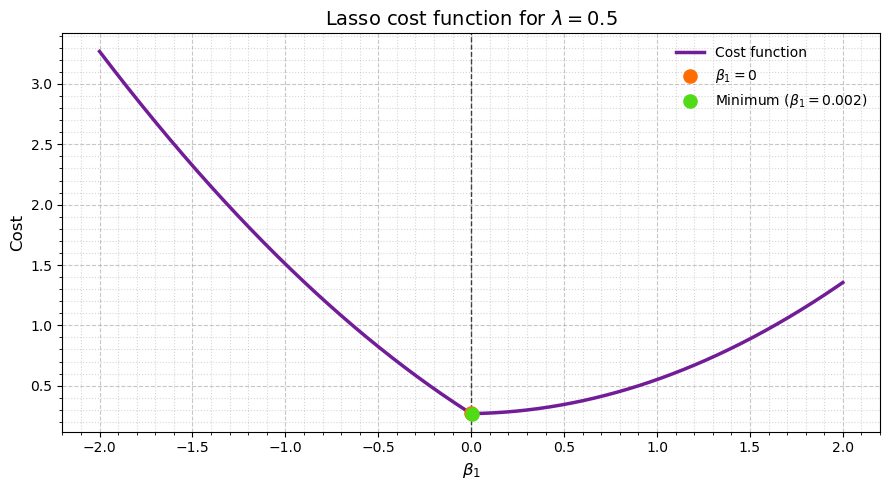

In [14]:
cost = compute_cost(lambda_=0.5)

min_idx = np.argmin(cost)
beta_min = beta_1[min_idx]
cost_min = cost[min_idx]

zero_idx = np.argmin(np.abs(beta_1 - 0))
cost_zero = cost[zero_idx]

plt.figure(figsize=(9, 5))

plt.plot(
    beta_1,
    cost,
    linewidth=2.5,
    color="#721d98",
    label="Cost function"
)

plt.scatter(
    0,
    cost_zero,
    s=90,
    color="#ff6d00",
    zorder=5,
    label=r"$\beta_1 = 0$"
)

plt.scatter(
    beta_min,
    cost_min,
    s=90,
    color="#51da16",
    zorder=5,
    label=fr"Minimum ($\beta_1={beta_min:.3f}$)"
)

plt.xlabel(r"$\beta_1$", fontsize=12)
plt.ylabel("Cost", fontsize=12)
plt.title(r"Lasso cost function for $\lambda = 0.5$", fontsize=14)

ax = plt.gca()

ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))

ax.grid(which="major", alpha=0.7, linestyle="--")
ax.grid(which="minor", alpha=0.5, linestyle=":")

ax.axvline(
    0,
    linewidth=1,
    alpha=0.7,
    color='black',
    linestyle="--"
)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [9]:
float(round(min(cost), 3))

0.269

As expected, nothing changes. And same goes for $\lambda=5,10,1000\dots$

Before we round up, let's generate a grid of 100 equally spaced lambdas between $0$ and $\lambda_{lim}$ and try to find for which of them Lasso and Ridge minimise their respective costs, and how those minimum costs compare. Before you look at the result do you expect some amount of regularisation to help lower the smallest possible cost of our simple $f$ model?

In [10]:
lambdas = np.linspace(0, lambda_lim, 100)

costs_lasso = [min([np.mean(np.square(y-beta_0[i]-beta_1[i]*x)) + lam*abs(beta_1[i]) for i in range(res)]) for lam in lambdas]
costs_ridge = [min([np.mean(np.square(y-beta_0[i]-beta_1[i]*x)) + lam*(beta_1[i])**2 for i in range(res)]) for lam in lambdas]

print('Lasso smallest cost: ', round(min(costs_lasso), 3), ', reached with lambda =', lambdas[np.argmin(costs_lasso)])
print('Ridge smallest cost: ', round(min(costs_ridge), 3), ', reached with lambda =', lambdas[np.argmin(costs_ridge)])

Lasso smallest cost:  0.049 , reached with lambda = 0.0
Ridge smallest cost:  0.049 , reached with lambda = 0.0


Does this result surprise you? Did you expect something else? Turns out zero regularisation yields the lowest cost with both Lasso and Ridge. One could say this is because the very problem mentioned by Hastie \& Tibshirani in the interlude does not exist here, since we're working with only one feature ($x$), so any regularisation does more harm than good in this excruciatingly simple dataset with zero collinearity. Anyway, our goal here was just to understand how those two regularisation methods work, and our simple model does the job even though regularisation is of no use here.

### Conclusion

Thanks to those nice visualisations, we were able to understand what happens to the shape of the Lasso cost function as we vary the regularisation strength $\lambda$. The more $\lambda$ goes up, the less smooth the cost curve looks, and an "elbow effect" starts showing up at $\beta_1=0$ which eventually ends up becoming the global minimum of the cost once $\lambda$ reached $\lambda_{lim}$ and beyond. That is how some coefficients end up (contrary to Ridge) actually zero'ed out with enough regularisation, and that's what the Lasso algorithm decides to do when there's serious collinearity in your dataset.

You're now ready to show those employees that not enough red bull always had the potential to end their career.

<center><img src="end-career-supa.png" alt="drawing" width="400"/></center>
